#**Decision Trees for Swine Flu Detection**
---

<br>**Dataset Explanation:** We will work on a Swine Flu dataset that tells us if a person has the flu or not based on the symptoms he/she is experiencing. The columns in this dataset are:<br>
* Chills: A feature telling if the person has chills or not.
* Runny nose: A feature telling if the person has a runny nose or not.
* Headache: A feature telling the level of headache that a person is experiencing (It could be Miild, Moderate, or No headache).
* Fever: A feature telling if the person has fever or not.
* Flu: The target value that tells us if the person has the flu or not.

#Importing Librarires

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing

#Loading the Dataset

For this notebook we will work with the flu.csv file we've seen earlier

First we need to take a look at the dataset before starting to work on it.

In [2]:
df = pd.read_csv('flu.csv')
df.head()

,Chills,runny nose,head ache,fever,Flu
0,Y,N,Mild,Y,N
1,Y,Y,No,N,Y
2,Y,N,Strong,Y,Y
3,N,Y,Mild,Y,Y
4,N,N,No,N,N


As we can see, we have 4 features that will predict if the person has the Swine Flu or not.

Let's check the shape of our data.

In [3]:
df.shape

(8, 5)

So we have 8 examples in this dataset (A small one! Will be good enough for our demonstration purposes).

Let's next explore some information about it.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Chills      8 non-null      str  
 1   runny nose  8 non-null      str  
 2   head ache   8 non-null      str  
 3   fever       8 non-null      str  
 4   Flu         8 non-null      str  
dtypes: str(5)
memory usage: 452.0 bytes


We do not have any missing values. However, all our features and target variables are of data type object which we can't feed to the model, so we need to clean those.

#Dataset Preprocessing

## Converting Categorical Features to Numerical

First thing to consider is changing the categorical features to Numerical in order to feed them to the algorithm so we are able to run the classification.

This would be useful when we use the decision trees later as well.

In [5]:
encoder = preprocessing.LabelEncoder()
df['Chills'] = encoder.fit_transform(df['Chills'])
df['runny nose'] = encoder.fit_transform(df['runny nose'])
df['head ache'] = encoder.fit_transform(df['head ache'])
df['fever'] = encoder.fit_transform(df['fever'])
df['Flu'] = encoder.fit_transform(df['Flu'])

df.head(8)

,Chills,runny nose,head ache,fever,Flu
0,1,0,0,1,0
1,1,1,1,0,1
2,1,0,2,1,1
3,0,1,0,1,1
4,0,0,1,0,0
5,0,1,2,1,1
6,0,1,2,0,0
7,1,1,0,1,1




---

#Decision Trees

Now, you have to solve the same problem but using decision trees that we learned about.

**Question 1:** Import DecisionTreeClassifier, prepare X and Y, and fit your classifier

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn import metrics
from sklearn.metrics import accuracy_score, classification_report

X = df.drop('Flu', axis=1)
y = df['Flu']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)



,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

##Printing Text Structure of the tree

**Question 2:** Check how you can print the text structure of the built tree using sklearn lirary

In [7]:
tree_rules = export_text(clf, feature_names=list(X.columns))
print("Decision Tree Rules:\n", tree_rules)

Decision Tree Rules:
 |--- runny nose <= 0.50
|   |--- head ache <= 1.50
|   |   |--- class: 0
|   |--- head ache >  1.50
|   |   |--- class: 1
|--- runny nose >  0.50
|   |--- class: 1



##Plotting the tree to see its structure

**Question 3:** Plot the tree structure to see nodes and gini index at the nodes level

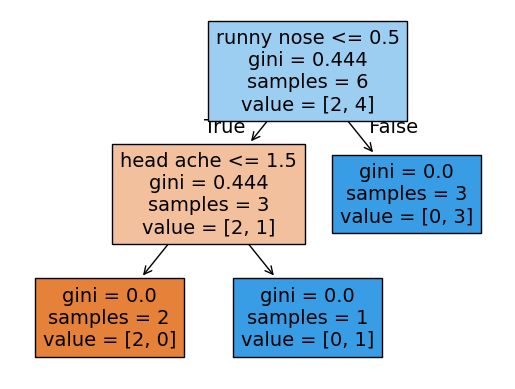

In [8]:
plot_tree(clf, filled=True, feature_names=list(X.columns))
plt.show()

##Predicting using a Decision Tree

**Question 4:** Confirm the prediction result you got using Naive Bayes previously

In [9]:
print(clf.predict([[1,1,1,1]]))

print(clf.predict_proba([[1,1,1,1]]))

[1]
[[0. 1.]]


/Users/rasha/Desktop/AI-projects/SDAIA-Machine-Learning-Bootcamp/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/Users/rasha/Desktop/AI-projects/SDAIA-Machine-Learning-Bootcamp/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Once again, we get the same result from our DT as our NB algorithm.

In [10]:
y_pred = clf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")

Accuracy: 0.500
